In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

movies = pd.read_csv("/kaggle/input/datasets/durgamalleswaris/movie-data-analysis/tmdb_5000_movies.csv")
credits = pd.read_csv("/kaggle/input/datasets/durgamalleswaris/movie-data-analysis/tmdb_5000_credits.csv")

print("Movies:", movies.shape)
print("Credits:", credits.shape)

display(movies.head())
display(credits.head())

Movies: (4803, 20)
Credits: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [2]:
df = movies.merge(
    credits,
    left_on="id",
    right_on="movie_id",
    how="inner"
)

print("Merged Dataset Shape:", df.shape)

display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Merged Dataset Shape: (4803, 24)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."



Columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average', 'vote_count', 'movie_id', 'title_y', 'cast', 'crew']


In [3]:
print(df.columns.tolist())

['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average', 'vote_count', 'movie_id', 'title_y', 'cast', 'crew']


In [4]:
df = df[[
    "id",
    "title_x",
    "overview",
    "genres",
    "keywords",
    "cast",
    "crew",
    "vote_average",
    "vote_count",
    "popularity"
]]

df = df.dropna(subset=["title_x", "overview"])
df = df.drop_duplicates("id")

df = df.rename(columns={"title_x": "title"})

print("Cleaned Shape:", df.shape)
display(df[["title", "vote_average", "popularity"]].head())

Cleaned Shape: (4800, 10)


,title,vote_average,popularity
0,Avatar,7.2,150.437577
1,Pirates of the Caribbean: At World's End,6.9,139.082615
2,Spectre,6.3,107.376788
3,The Dark Knight Rises,7.6,112.312950
4,John Carter,6.1,43.926995


In [5]:
df["genres"] = df["genres"].fillna("")
df["keywords"] = df["keywords"].fillna("")
df["cast"] = df["cast"].fillna("")

df["features"] = (
    df["genres"] + " " +
    df["keywords"] + " " +
    df["cast"]
)

display(df[["title", "features"]].head())

,title,features
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam..."
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["features"])
similarity = cosine_similarity(tfidf_matrix)

indices = pd.Series(df.index, index=df["title"].str.lower()).drop_duplicates()

def recommend(movie, n=5):
    movie = movie.lower()

    if movie not in indices:
        return pd.DataFrame({"Recommended Movies": ["Movie not found"]})

    idx = indices[movie]
    scores = sorted(
        enumerate(similarity[idx]),
        key=lambda x: x[1],
        reverse=True
    )[1:n+1]

    movie_indices = [i[0] for i in scores]

    return df.iloc[movie_indices][
        ["title", "vote_average", "popularity"]
    ].reset_index(drop=True)

display(recommend("Avatar"))

,title,vote_average,popularity
0,American Gangster,7.4,42.361215
1,The Dark Knight,8.2,187.322927
2,Spider-Man 3,5.9,115.699814
3,The Life of David Gale,7.3,22.442241
4,Inherent Vice,6.5,45.742217


,title,vote_average,vote_count
1881,The Shawshank Redemption,8.5,8205
3337,The Godfather,8.4,5893
3232,Pulp Fiction,8.3,8428
3865,Whiplash,8.3,4254
2294,Spirited Away,8.3,3840
662,Fight Club,8.3,9413
1818,Schindler's List,8.3,4329
2731,The Godfather: Part II,8.3,3338
65,The Dark Knight,8.2,12002
2247,Princess Mononoke,8.2,1983


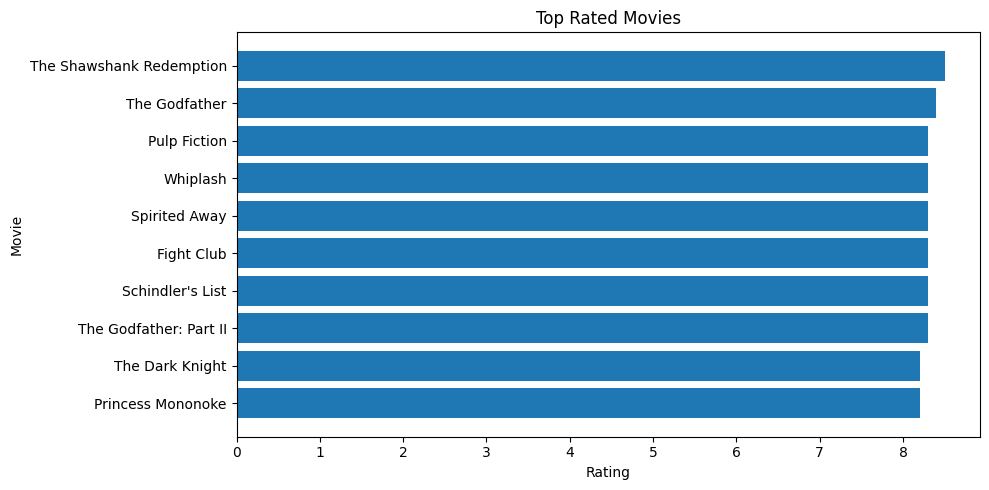

In [7]:
top_rated = (
    df[df["vote_count"] >= 1000]
    .sort_values("vote_average", ascending=False)
    .head(10)
)

display(top_rated[["title", "vote_average", "vote_count"]])

plt.figure(figsize=(10, 5))
plt.barh(
    top_rated["title"][::-1],
    top_rated["vote_average"][::-1]
)
plt.title("Top Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

In [8]:
print("===== FINAL INSIGHTS =====")

print("1. The system recommends movies based on similar genres, keywords, and cast.")
print("2. TF-IDF converts movie features into numerical representations.")
print("3. Cosine similarity identifies movies with similar content.")
print("4. The rating analysis highlights highly rated movies with strong audience engagement.")
print("5. Content-based recommendations help users discover movies similar to their interests.")

print("\n===== CONCLUSION =====")

print("The Movie Recommendation System successfully recommends similar movies")
print("using content-based filtering. This project demonstrates data cleaning,")
print("feature engineering, TF-IDF, cosine similarity, recommendation, and visualization.")

===== FINAL INSIGHTS =====
1. The system recommends movies based on similar genres, keywords, and cast.
2. TF-IDF converts movie features into numerical representations.
3. Cosine similarity identifies movies with similar content.
4. The rating analysis highlights highly rated movies with strong audience engagement.
5. Content-based recommendations help users discover movies similar to their interests.

===== CONCLUSION =====
The Movie Recommendation System successfully recommends similar movies
using content-based filtering. This project demonstrates data cleaning,
feature engineering, TF-IDF, cosine similarity, recommendation, and visualization.


In [9]:
movie_list = ["Avatar", "Titanic", "The Dark Knight"]

for movie in movie_list:
    print(f"\n🎬 Recommendations for: {movie}")
    display(recommend(movie, 5))


🎬 Recommendations for: Avatar


,title,vote_average,popularity
0,American Gangster,7.4,42.361215
1,The Dark Knight,8.2,187.322927
2,Spider-Man 3,5.9,115.699814
3,The Life of David Gale,7.3,22.442241
4,Inherent Vice,6.5,45.742217



🎬 Recommendations for: Titanic


,title,vote_average,popularity
0,You Don't Mess with the Zohan,5.5,40.597344
1,GoodFellas,8.2,63.654244
2,Mr. Smith Goes to Washington,7.9,12.262400
3,Hot Pursuit,5.4,18.262017
4,Batman v Superman: Dawn of Justice,5.7,155.790452



🎬 Recommendations for: The Dark Knight


,title,vote_average,popularity
0,American Gangster,7.4,42.361215
1,The Dark Knight Rises,7.6,112.312950
2,Spider-Man 3,5.9,115.699814
3,The Life of David Gale,7.3,22.442241
4,Batman v Superman: Dawn of Justice,5.7,155.790452


In [10]:
import ast

def get_director(crew):
    try:
        crew_list = ast.literal_eval(crew)
        for person in crew_list:
            if person.get("job") == "Director":
                return person.get("name", "")
    except:
        return ""
    return ""

df["director"] = df["crew"].apply(get_director)

df["features"] = (
    df["genres"] + " " +
    df["keywords"] + " " +
    df["cast"] + " " +
    df["director"]
)

display(df[["title", "director", "features"]].head())

,title,director,features
0,Avatar,James Cameron,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
1,Pirates of the Caribbean: At World's End,Gore Verbinski,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""..."
2,Spectre,Sam Mendes,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
3,The Dark Knight Rises,Christopher Nolan,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam..."
4,John Carter,Andrew Stanton,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["features"])
similarity = cosine_similarity(tfidf_matrix)

indices = pd.Series(df.index, index=df["title"].str.lower()).drop_duplicates()

def recommend(movie, n=5):
    movie = movie.lower()

    if movie not in indices:
        return pd.DataFrame({"Recommended Movies": ["Movie not found"]})

    idx = indices[movie]
    scores = sorted(
        enumerate(similarity[idx]),
        key=lambda x: x[1],
        reverse=True
    )[1:n+1]

    return df.iloc[
        [i[0] for i in scores]
    ][["title", "director", "vote_average"]].reset_index(drop=True)

display(recommend("Avatar", 5))

,title,director,vote_average
0,American Gangster,Ridley Scott,7.4
1,The Dark Knight,Christopher Nolan,8.2
2,Spider-Man 3,Sam Raimi,5.9
3,The Life of David Gale,Alan Parker,7.3
4,Inherent Vice,Paul Thomas Anderson,6.5
